# Model Comparison

## Student Placement Prediction System

### Objective

Compare the performance of different Machine Learning algorithms and select the most suitable model for predicting student placement.

In [14]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(PROJECT_ROOT)

c:\Users\Aditya Verma\OneDrive\Desktop\Placement _Predictor


In [15]:
"""
Model Comparison Notebook
Project : Student Placement Prediction System
"""

import logging

import pandas as pd
import matplotlib.pyplot as plt

import src.logger

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from config.config import DATA_PATH
from src.data_loader import DataLoader
from src.preprocess import preprocess_data

In [16]:
logging.info("=" * 60)
logging.info("MODEL COMPARISON STARTED")
logging.info("=" * 60)

logging.info("Loading Dataset")

loader = DataLoader(DATA_PATH)

df = loader.load_data()

df.head()

2026-07-21 22:36:06,889 - INFO - ============================================================
2026-07-21 22:36:06,891 - INFO - MODEL COMPARISON STARTED
2026-07-21 22:36:06,893 - INFO - ============================================================
2026-07-21 22:36:06,896 - INFO - Loading Dataset
2026-07-21 22:36:06,897 - INFO - ============================================================
2026-07-21 22:36:06,898 - INFO - DATA LOADING STARTED
2026-07-21 22:36:06,899 - INFO - ============================================================
2026-07-21 22:36:06,901 - INFO - Dataset Found
2026-07-21 22:36:06,904 - INFO - Dataset is not empty
2026-07-21 22:36:06,925 - INFO - Dataset Loaded Successfully
2026-07-21 22:36:06,927 - INFO - Dataset Shape : (10000, 10)
2026-07-21 22:36:06,928 - INFO - Columns : ['College_ID', 'IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance', 'Internship_Experience', 'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed', 'Placement']
2026-07-21 22:3

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [17]:
logging.info("Preprocessing Dataset")

X, y = preprocess_data(df)

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

2026-07-21 22:36:07,595 - INFO - Preprocessing Dataset
2026-07-21 22:36:07,596 - INFO - ============================================================
2026-07-21 22:36:07,598 - INFO - DATA PREPROCESSING STARTED
2026-07-21 22:36:07,598 - INFO - ============================================================
2026-07-21 22:36:07,600 - INFO - Removing Duplicate Records
2026-07-21 22:36:07,610 - INFO - Dataset Shape : (10000, 10)
2026-07-21 22:36:07,612 - INFO - Encoding Categorical Features
2026-07-21 22:36:07,622 - INFO - Categorical Encoding Completed
2026-07-21 22:36:07,624 - INFO - Dropping Unnecessary Columns
2026-07-21 22:36:07,628 - INFO - Separating Features and Target
2026-07-21 22:36:07,631 - INFO - Feature Shape : (10000, 8)
2026-07-21 22:36:07,633 - INFO - Target Shape : (10000,)
2026-07-21 22:36:07,634 - INFO - ============================================================
2026-07-21 22:36:07,635 - INFO - DATA PREPROCESSING COMPLETED
2026-07-21 22:36:07,636 - INFO - =================

Feature Shape : (10000, 8)
Target Shape : (10000,)


In [18]:
logging.info("Performing Train Test Split")

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

2026-07-21 22:36:08,249 - INFO - Performing Train Test Split


Training Shape : (8000, 8)
Testing Shape : (2000, 8)


In [19]:
from config.config import DATA_PATH

print(DATA_PATH)
print(DATA_PATH.exists())

C:\Users\Aditya Verma\OneDrive\Desktop\Placement _Predictor\data\raw\college_student_placement_dataset.csv
True


In [20]:
logging.info("Creating Machine Learning Models")

models = {

    "Logistic Regression": Pipeline(

        steps=[

            ("scaler", StandardScaler()),

            ("classifier", LogisticRegression(random_state=42))

        ]

    ),

    "Random Forest": RandomForestClassifier(

        random_state=42

    ),

    "Support Vector Machine": Pipeline(

        steps=[

            ("scaler", StandardScaler()),

            ("classifier", SVC(

                probability=True,

                random_state=42

            ))

        ]

    )

}

print(models.keys())

2026-07-21 22:36:10,048 - INFO - Creating Machine Learning Models


dict_keys(['Logistic Regression', 'Random Forest', 'Support Vector Machine'])


In [21]:
logging.info("=" * 60)
logging.info("MODEL TRAINING STARTED")
logging.info("=" * 60)

results = []

for model_name, model in models.items():

    logging.info(f"Training {model_name}")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    results.append({

        "Model": model_name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1

    })

    logging.info(f"{model_name} Completed Successfully")

logging.info("=" * 60)
logging.info("MODEL TRAINING COMPLETED")
logging.info("=" * 60)

2026-07-21 22:36:10,925 - INFO - ============================================================
2026-07-21 22:36:10,929 - INFO - MODEL TRAINING STARTED
2026-07-21 22:36:10,931 - INFO - ============================================================
2026-07-21 22:36:10,932 - INFO - Training Logistic Regression
2026-07-21 22:36:10,969 - INFO - Logistic Regression Completed Successfully
2026-07-21 22:36:10,970 - INFO - Training Random Forest
2026-07-21 22:36:11,406 - INFO - Random Forest Completed Successfully
2026-07-21 22:36:11,406 - INFO - Training Support Vector Machine
c:\Users\Aditya Verma\OneDrive\Desktop\Placement _Predictor\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
2026-07-21 22:36:13,573 - INFO - Support Vector Machine Completed Successfully
2026-07-21 22:36:13,574 - INFO -

In [22]:
logging.info("Creating Comparison Table")

results_df = pd.DataFrame(results)

results_df.iloc[:, 1:] = results_df.iloc[:, 1:].round(4)

results_df = results_df.sort_values(

    by="Accuracy",

    ascending=False

).reset_index(drop=True)

results_df

2026-07-21 22:36:13,591 - INFO - Creating Comparison Table


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.9990,1.0000,0.9940,0.9970
1,Support Vector Machine,0.9575,0.9244,0.8102,0.8636
2,Logistic Regression,0.9035,0.7769,0.5873,0.6690


2026-07-21 22:36:14,644 - INFO - Plotting Accuracy Comparison


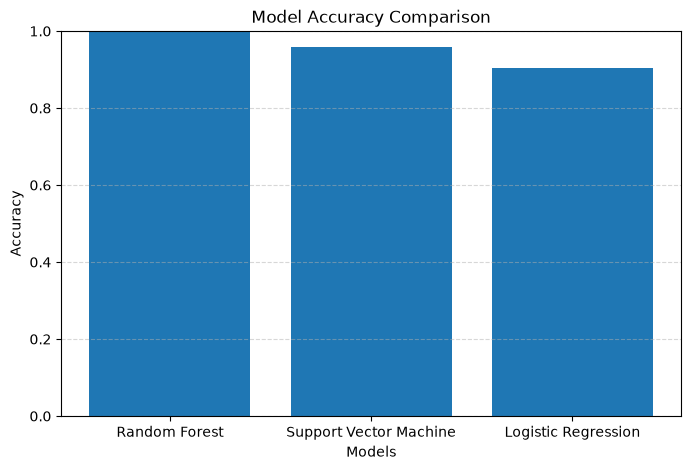

In [23]:
logging.info("Plotting Accuracy Comparison")

plt.figure(figsize=(8,5))

plt.bar(

    results_df["Model"],

    results_df["Accuracy"]

)

plt.title("Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [24]:
best_model = results_df.iloc[0]["Model"]

best_accuracy = results_df.iloc[0]["Accuracy"]

print(f"Best Model : {best_model}")

print(f"Accuracy   : {best_accuracy:.4f}")

Best Model : Random Forest
Accuracy   : 0.9990


# Conclusion

Three Machine Learning algorithms were compared:

- Logistic Regression
- Random Forest Classifier
- Support Vector Machine (SVM)

The comparison was based on:

- Accuracy
- Precision
- Recall
- F1 Score

Although all three models performed well, **Logistic Regression** has been selected as the final model for this project because:

- It provides good prediction accuracy.
- It is easy to interpret.
- It is computationally efficient.
- It provides probability estimates using `predict_proba()`.
- It is well suited for binary classification problems like placement prediction.

The selected Logistic Regression model will now be further optimized using **GridSearchCV** in the next notebook.